In [1]:
#### python
import os
import sys
import importlib
# columnar analysis
from coffea import processor
from coffea.nanoevents import NanoAODSchema
import awkward as ak
from dask.distributed import Client, performance_report
# local
sidm_path = str(os.getcwd()).split("/sidm")[0]
if sidm_path not in sys.path: sys.path.insert(1, sidm_path)
from sidm.tools import utilities, sidm_processor, scaleout, llpnanoaodschema
# always reload local modules to pick up changes during development
importlib.reload(utilities)
importlib.reload(sidm_processor)
importlib.reload(scaleout)
# plotting
import matplotlib.pyplot as plt
utilities.set_plot_style()
%matplotlib inline
import coffea.util
from matplotlib.colors import LogNorm
from master import *

## Start plotting

In [18]:
vr = "07"
sss = "2Mu2E_500GeV_5p0GeV_0p8mm"
# channels = ["baseNoLj", "master_allevt", "baseNoLj_noTrigger"] #sel.yaml
channels = ["baseNoLjNoLjsource_noTrigger", "baseNoLjNoLjsource", "baseNoLj", "master_allevt", ] #sel.yaml

ch1 = channels[0] # gen cuts, and pv filter
ch2 = channels[1] # apply trigger, gen cuts, and pv filter
ch3 = channels[2] # ljsources
ch4 = channels[3] # my selections


cha = [ch1, ch2, ch3]

### Gen quantities

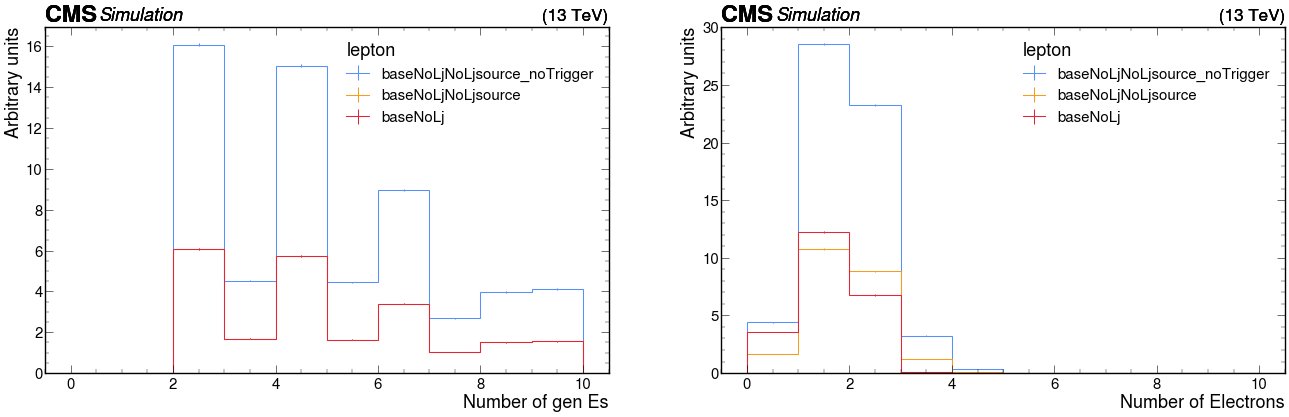

In [20]:
# n
npl = 2
out2 = coffea.util.load("outputs/master_2mu_" + vr + ".coffea")
# out4 = coffea.util.load("outputs/master_4mu_" + vr + ".coffea")

plt.subplots(1,npl, figsize=(32,9))

plt.subplot(1, npl, 1)
for ch in cha:
    utilities.plot(out2[sss]["hists"]["genE_n"][ch, :], label = ch, density=False)
    # utilities.plot(out2[sss]["hists"]["electron_n"][ch1, :], label = "reco", density=False)
plt.legend(title="lepton", alignment="left", loc=0)
plt.ylabel("Arbitrary units")
plt.xlabel("Number of gen Es")

plt.subplot(1, npl, 2)
for ch in cha:
    utilities.plot(out2[sss]["hists"]["electron_n"][ch, :], label = ch, density=False)
    # utilities.plot(out2[sss]["hists"]["electron_n"][ch1, :], label = "reco", density=False)
plt.legend(title="lepton", alignment="left", loc=0)
plt.ylabel("Arbitrary units")
# plt.xlabel("Number of gen Es")

# plt.subplot(1, npl, 2)
# for sss in mxx_2mu:
#     print(sss)
#     utilities.plot(out2[sss]["hists"]["electron_n"][ch1, :], label = sss, density=False)
# plt.legend(title="Sample", alignment="left", loc=0)
# plt.ylabel("Arbitrary units")
# plt.xlabel("Number of gen Es")


# plt.subplot(1, npl, 2)
# for sss in mxx_4mu:
#     utilities.plot(out4[sss]["hists"]["genMu_n"][ch2, ::2j], label = sig_4mu, density=True)
# plt.legend(sig_2mu, alignment="left", loc= 0)
# plt.ylabel("Arbitrary units")
# plt.xlabel("Number of genMus")
plt.savefig(f"gen_plots/gen_{vr}_n", bbox_inches="tight")

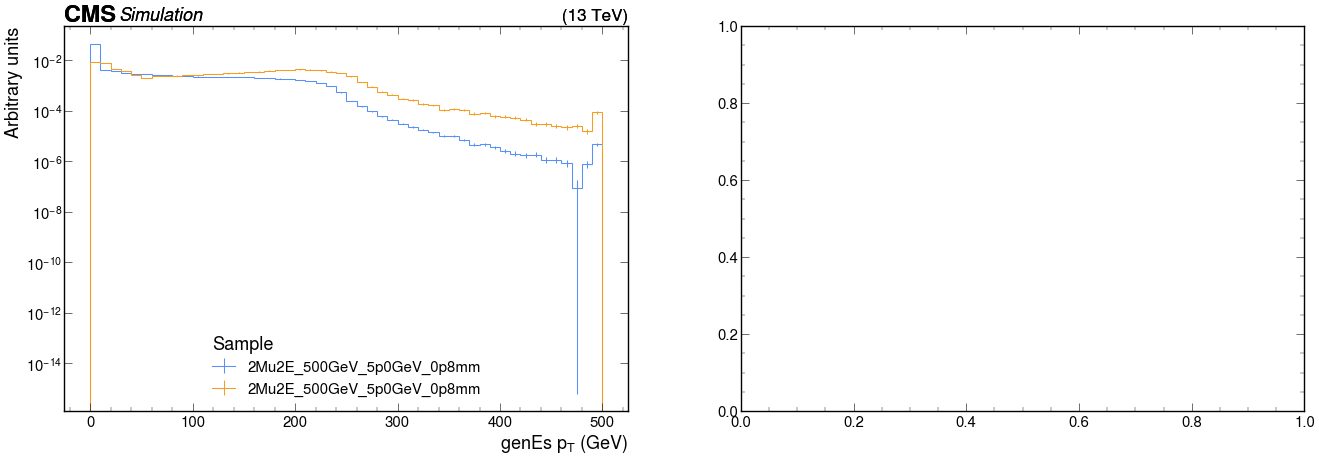

In [14]:
# pt
# sss = "2Mu2E_500GeV_1p2GeV_19p0mm"
plt.subplots(1, 2, figsize=(2*fw, fh))
plt.subplot(1, 2, 1)
# for sss in mxx_2mu:
utilities.plot(out2["2Mu2E_500GeV_5p0GeV_0p8mm"]["hists"]["genE_pt"][ch4, ::2j], label = sss, density=True)
utilities.plot(out2["2Mu2E_500GeV_5p0GeV_0p8mm"]["hists"]["electron_pt"][ch2, ::2j], label = sss, density=True)
plt.legend(title="Sample", alignment="left", loc=0)
plt.ylabel("Arbitrary units")
plt.yscale("log")

# plt.subplot(1, npl, 2)
# for sss in mxx_4mu:
#     utilities.plot(out4[sss]["hists"]["genMu_pt"][ch1, ::2j], label = sss, density=True)
# plt.legend(title="Sample", alignment="left", loc="upper right")
# plt.ylabel("Arbitrary units")
# plt.yscale("log")
# plt.savefig(f"plots/master_{vr}_n", bbox_inches="tight")

In [ ]:
# n
npl = 3
plt.subplots(1, npl, figsize=(npl*fw, fh))
plt.subplot(1, npl, 1)
for sss in mxx_2mu:
    utilities.plot(out2[sss]["hists"]["electron_n"][ch1, ::2j], label = sig_2mu, density=True)
plt.legend(sig_2mu, title="Sample", alignment="left", loc="upper right")
plt.ylabel("Arbitrary units")

plt.subplot(1, npl, 2)
for sss in mxx_4mu:
    utilities.plot(out4[sss]["hists"]["muon_n"][ch1, ::2j], label = sss, density=True)
plt.legend(title="Sample", alignment="left", loc="upper right")
plt.ylabel("Arbitrary units")

plt.subplot(1, npl, 3)
for sss in mxx_4mu:
    utilities.plot(out4[sss]["hists"]["dsaMuon_n"][ch1, ::2j], label = sig_4mu, density=True)
plt.legend(title="Sample", alignment="left", loc="upper right")
plt.ylabel("Arbitrary units")

# plt.savefig(f"plots/master_{vr}_n", bbox_inches="tight")

In [ ]:
raise SystemExit("Notebook stopped intentionally after this cell.")

In [ ]:
# dxy
plt.subplots(1, npl, figsize=(npl*figw, figh))
plt.subplot(1, npl, 1)
for sss in sig_2mu:
    utilities.plot(out[sss]["hists"]["genE_dxy"][ch1, ::2j], label = sig_2mu, density=True)
    plt.legend(sig_2mu, title="Sample", alignment="left", loc="upper right")
    plt.ylabel("Arbitrary units")

plt.subplot(1, npl, 2)
for sss in sig_4mu:
    utilities.plot(out[sss]["hists"]["genMu_dxy"][ch1, ::2j], label = sig_4mu, density=True)
    plt.legend(sig_2mu, title="Sample", alignment="left", loc="upper right")
    plt.ylabel("Arbitrary units")
# plt.savefig(f"plots/master_{vr}_dxy", bbox_inches="tight")

In [ ]:
# eta_phi
# plt.subplots(1, npl, figsize=(npl*figw, figh))
# plt.subplot(1, npl, 1)
# for sss in sig_2mu:
#     utilities.plot(out[sss]["hists"]["genE_eta_phi"][ch1, :, :].project("genE_eta"), )
#     plt.legend(sig_2mu, title="Sample", alignment="left", loc="upper right")
#     plt.ylabel("Arbitrary units")

# plt.subplot(1, npl, 2)
# for sss in sig_4mu:
#     utilities.plot(out[sss]["hists"]["muon_eta_phi"][ch1, :, :].project("muons_eta"), )
#     plt.legend(sig_2mu, title="Sample", alignment="left", loc="upper right")
#     plt.ylabel("Arbitrary units")

# plt.subplot(1, npl, 3)
# for sss in sig_4mu:
#     utilities.plot(out[sss]["hists"]["dsaMuon_n"][ch1, ::2j], label = sig_4mu, density=True)
#     plt.legend(sig_2mu, title="Sample", alignment="left", loc="upper right")
#     plt.ylabel("Arbitrary units")

In [ ]:
# pt
plt.subplots(1, npl, figsize=(npl*figw, figh))
plt.subplot(1, npl, 1)
for sss in sig_2mu:
    utilities.plot(out[sss]["hists"]["genE_pt"][ch1, ::2j], label = sig_2mu, density=True)
    plt.legend(sig_2mu, title="Sample", alignment="left", loc="upper right")
    plt.ylabel("Arbitrary units")

plt.subplot(1, npl, 2)
for sss in sig_4mu:
    utilities.plot(out[sss]["hists"]["genMu_pt"][ch1, ::2j], label = sig_4mu, density=True)
    plt.legend(sig_2mu, title="Sample", alignment="left", loc="upper right")
    plt.ylabel("Arbitrary units")
# plt.savefig(f"plots/master_{vr}_pt", bbox_inches="tight")

In [ ]:
# leading pt
plt.subplots(1, npl, figsize=(npl*figw, figh))
plt.subplot(1, npl, 1)
for sss in sig_2mu:
    utilities.plot(out[sss]["hists"]["genE0_pt"][ch1, ::2j], label = sig_2mu, density=True)
    plt.legend(sig_2mu, title="Sample", alignment="left", loc="upper right")
    plt.ylabel("Arbitrary units")

plt.subplot(1, npl, 2)
for sss in sig_4mu:
    utilities.plot(out[sss]["hists"]["genMu0_pt"][ch1, ::2j], label = sig_4mu, density=True)
    plt.legend(sig_2mu, title="Sample", alignment="left", loc="upper right")
    plt.ylabel("Arbitrary units")
# plt.savefig(f"plots/master_{vr}_Lead_pt", bbox_inches="tight")

In [ ]:
# sleading pt
plt.subplots(1, npl, figsize=(npl*figw, figh))
plt.subplot(1, npl, 1)
for sss in sig_2mu:
    utilities.plot(out[sss]["hists"]["genE1_pt"][ch1, ::2j], label = sig_2mu, density=True)
    plt.legend(sig_2mu, title="Sample", alignment="left", loc="upper right")
    plt.ylabel("Arbitrary units")

plt.subplot(1, npl, 2)
for sss in sig_4mu:
    utilities.plot(out[sss]["hists"]["genMu1_pt"][ch1, ::2j], label = sig_4mu, density=True)
    plt.legend(sig_2mu, title="Sample", alignment="left", loc="upper right")
    plt.ylabel("Arbitrary units")

# plt.savefig(f"plots/master_{vr}_sLead_pt", bbox_inches="tight")

In [ ]:
# dR
plt.subplots(1, npl, figsize=(npl*figw, figh))
plt.subplot(1, npl, 1)
for sss in sig_2mu:
    utilities.plot(out[sss]["hists"]["genE_genE_dR"][ch1, ::2j], label = sig_2mu, density=True)
    plt.legend(sig_2mu, title="Sample", alignment="left", loc="upper right")
    plt.ylabel("Arbitrary units")

plt.subplot(1, npl, 2)
for sss in sig_4mu:
    utilities.plot(out[sss]["hists"]["genMu_genMu_dR"][ch1, ::2j], label = sig_4mu, density=True)
    plt.legend(sig_2mu, title="Sample", alignment="left", loc="upper right")
    plt.ylabel("Arbitrary units")

# plt.savefig(f"plots/master_{vr}_dR", bbox_inches="tight")

## Reco quantities

In [ ]:
figw, figh, = 12, 10

In [ ]:
# n
npl = 3
plt.subplots(1, npl, figsize=(npl*fw, fh))
plt.subplot(1, npl, 1)
for sss in mxx_2mu:
    utilities.plot(out2[sss]["hists"]["electron_n"][ch1, ::2j], label = sig_2mu, density=True)
plt.legend(sig_2mu, title="Sample", alignment="left", loc="upper right")
plt.ylabel("Arbitrary units")

plt.subplot(1, npl, 2)
for sss in mxx_4mu:
    utilities.plot(out4[sss]["hists"]["muon_n"][ch1, ::2j], label = sss, density=True)
plt.legend(title="Sample", alignment="left", loc="upper right")
plt.ylabel("Arbitrary units")

plt.subplot(1, npl, 3)
for sss in mxx_4mu:
    utilities.plot(out4[sss]["hists"]["dsaMuon_n"][ch1, ::2j], label = sig_4mu, density=True)
plt.legend(title="Sample", alignment="left", loc="upper right")
plt.ylabel("Arbitrary units")

# plt.savefig(f"plots/master_{vr}_n", bbox_inches="tight")

In [ ]:
# pt
npl = 3
plt.subplots(1, npl, figsize=(npl*figw, figh))

plt.subplot(1, npl, 1)
for sss in sig_2mu:
    utilities.plot(out[sss]["hists"]["electron_pt"][ch1, ::2j], label = sig_2mu, density=True)
    plt.legend(sig_2mu, title="Sample", alignment="left", loc="upper right")
    plt.ylabel("Arbitrary units")

plt.subplot(1, npl, 2)
for sss in sig_4mu:
    utilities.plot(out[sss]["hists"]["muon_pt"][ch1, ::2j], label = sig_4mu, density=True)
    plt.legend(sig_2mu, title="Sample", alignment="left", loc="upper right")
    plt.ylabel("Arbitrary units")

plt.subplot(1, npl, 3)
for sss in sig_4mu:
    utilities.plot(out[sss]["hists"]["dsaMuon_pt"][ch1, ::2j], label = sig_4mu, density=True)
    plt.legend(sig_2mu, title="Sample", alignment="left", loc="upper right")
    plt.ylabel("Arbitrary units")
    
# plt.savefig(f"plots/master_{vr}_pt", bbox_inches="tight")

In [ ]:
# eta_phi
npl = 3
plt.subplots(1, npl, figsize=(npl*figw, figh))

plt.subplot(1, npl, 1)
for sss in sig_2mu:
    utilities.plot(out[sss]["hists"]["electron_eta_phi"][ch1, :, :].project("electrons_eta"), )
    # utilities.plot(out[sss]["hists"]["electron_eta_phi"][ch1, ::2j], label = sig_2mu, density=True)
    plt.legend(sig_2mu, title="Sample", alignment="left", loc="upper right")
    plt.ylabel("Arbitrary units")

plt.subplot(1, npl, 2)
for sss in sig_4mu:
    utilities.plot(out[sss]["hists"]["muon_eta_phi"][ch1, :, :].project("muons_eta"), )
    # utilities.plot(out[sss]["hists"]["muon_pt"][ch1, ::2j], label = sig_4mu, density=True)
    plt.legend(sig_2mu, title="Sample", alignment="left", loc="upper right")
    plt.ylabel("Arbitrary units")

plt.subplot(1, npl, 3)
for sss in sig_4mu:
    utilities.plot(out[sss]["hists"]["dsaMuon_eta_phi"][ch1, :, :].project("dsaMuons_eta"), )
    plt.legend(sig_2mu, title="Sample", alignment="left", loc="upper right")
    plt.ylabel("Arbitrary units")

# plt.savefig(f"plots/master_{vr}_eta_phi", bbox_inches="tight")

In [ ]:
npl = 3
plt.subplots(1, npl, figsize=(npl*figw, figh))

plt.subplot(1, npl, 1)
for sss in sig_2mu:
    utilities.plot(out[sss]["hists"]["electron_n"][ch1, ::2j], label = sig_2mu, density=True)
    plt.legend(sig_2mu, title="Sample", alignment="left", loc=0)
    plt.ylabel("Arbitrary units")

plt.subplot(1, npl, 2)
for sss in sig_4mu:
    utilities.plot(out[sss]["hists"]["electron_pt"][ch1, ::2j], label = sig_4mu, density=True)
    plt.legend(sig_4mu, title="Sample", alignment="left", loc=0)
    plt.ylabel("Arbitrary units")

plt.subplot(1, npl, 3)
for sss in sig_4mu:
    utilities.plot(out[sss]["hists"]["dsaMuon_pt"][ch1, ::2j], label = sig_4mu, density=True)
    plt.legend(sig_2mu, title="Sample", alignment="left", loc="upper right")
    plt.ylabel("Arbitrary units")
    
# plt.savefig(f"plots/master_{vr}_pt", bbox_inches="tight")

In [ ]:
raise SystemExit("Notebook stopped intentionally after this cell.")

In [ ]:

npl = 2
plt.subplots(1, npl, figsize=(npl*figw, figh))
print(allsamples)
plt.subplot(1, npl, 1)
for sss in allsamples:
    # print(sss)
    utilities.plot(out[sss]["hists"]["electron_n"][ch1, ::2j], label = sig_2mu, density=True)
    plt.legend(allsamples, title="Sample", alignment="left", loc=0)
    # plt.title("den")
    plt.ylabel("Arbitrary units")

plt.subplot(1, npl, 2)
for sss in allsamples:
    utilities.plot(out[sss]["hists"]["electron_pt"][ch1, ::2j], label = sig_2mu, density=True)
    plt.legend(allsamples, title="Sample", alignment="left", loc=0)
    # plt.title("den")
    plt.ylabel("Arbitrary units")

# plt.subplot(1, npl, 3)
# for sss in allsamples[1:]:
#     utilities.plot(out[sss]["hists"]["lj_pt"][ch3, ::2j], label = sig_2mu, density=True)
#     plt.legend(allsamples, title="Sample", alignment="left", loc=0)
#     # plt.title("den")
#     plt.ylabel("Arbitrary units")

# plt.savefig(f"plots/BKG_{vr}_lj_pt", bbox_inches="tight")

In [ ]:
#pf dsa muons at mxx=100
for mu in ["pf", "dsa"]:
    fig, ax = plt.subplots(1, 3, figsize=(3*figw, figh))
    
    for fi, cl, lbl in zip(vr, cols, labels):    
        output = coffea.util.load("outputs/Eff_" + vr + ".coffea")
        out = output["out"]
        
        num, den = 0, 0
        for sss in allSamples[:5]:
            num = num + out[sss]["hists"]["num_genAs_toMu0_lxy_" + mu][ch2, ::2j]
            den = den + out[sss]["hists"]["den_genAs_toMu0_lxy"][ch2, ::2j]
        
        eff, errors = utilities.get_eff_hist(num, den)
        centers = num.axes[0].centers
        ax[0].errorbar(centers, eff, yerr=errors, fmt="o", color=cl, label=lbl, capsize=2)
    
    ax[0].set_ylabel("Efficiency")
    ax[0].set_xlabel("genAs $L_{xy}$ [cm]")
    ax[0].set_title(f"{mu} muons (L)")
    ax[0].set_ylim(0, 1.10)
    ax[0].legend(title=r"$\Delta R >$ ", loc=0)
    ax[0].grid(True, linestyle="--", alpha=0.6)
    
    #subleading muon
    for fi, cl, lbl in zip(vr, cols, labels):    
        output = coffea.util.load("outputs/Eff_" + vr + ".coffea")
        out = output["out"]

        num, den = 0, 0
        for sss in allSamples[:5]:
            num = num + out[sss]["hists"]["num_genAs_toMu1_lxy_" + mu][ch2, ::2j]
            den = den + out[sss]["hists"]["den_genAs_toMu1_lxy"][ch2, ::2j]
        
        eff, errors = utilities.get_eff_hist(num, den)
        centers = num.axes[0].centers
        ax[1].errorbar(centers, eff, yerr=errors, fmt="o", color=cl, label=lbl, capsize=2)
    
    ax[1].set_ylabel("Efficiency")
    ax[1].set_xlabel("genAs $L_{xy}$ [cm]")
    ax[1].set_title(f"{mu} muons (S)")
    ax[1].set_ylim(0, 1.10)
    ax[1].legend(title=r"$\Delta R >$ ", loc=0)
    ax[1].grid(True, linestyle="--", alpha=0.6)

    #leading + subleading muon
    for fi, cl, lbl in zip(vr, cols, labels):    
        output = coffea.util.load("outputs/Eff_" + vr + ".coffea")
        out = output["out"]

        num, den = 0, 0
        for sss in allSamples[:5]:
            num = num + out[sss]["hists"]["num_genAs_toMu0_lxy_" + mu][ch2, ::2j] + out[sss]["hists"]["num_genAs_toMu1_lxy_" + mu][ch2, ::2j]
            den = den + out[sss]["hists"]["den_genAs_toMu0_lxy"][ch2, ::2j] + out[sss]["hists"]["den_genAs_toMu1_lxy"][ch2, ::2j]
        
        eff, errors = utilities.get_eff_hist(num, den)
        centers = num.axes[0].centers
        ax[2].errorbar(centers, eff, yerr=errors, fmt="o", color=cl, label=lbl, capsize=2)
    
    ax[2].set_ylabel("Efficiency")
    ax[2].set_xlabel("genAs $L_{xy}$ [cm]")
    ax[2].set_title(f"{mu} muons (L+S)")
    ax[2].set_ylim(0, 1.10)
    ax[2].legend(title=r"$\Delta R >$ ", loc=0)
    ax[2].grid(True, linestyle="--", alpha=0.6)
    plt.tight_layout()
    # plt.savefig(f"plots/eff_35_{mu}_genA_lxy_m100.png", bbox_inches="tight")

In [ ]:
# My parameters
vr = "05"
numfiles = 10

#samples

sig_2mu = [
    "2Mu2E_100GeV_5p0GeV_0p4mm",
    # "2Mu2E_150GeV_5p0GeV_0p27mm",
    # "2Mu2E_200GeV_5p0GeV_0p2mm",
    "2Mu2E_500GeV_5p0GeV_0p08mm",
    # "2Mu2E_500GeV_5p0GeV_80p0mm",
    # "2Mu2E_800GeV_5p0GeV_0p05mm",
    # "2Mu2E_1000GeV_5p0GeV_0p04mm",
]

sig_4mu = [
    "4Mu_100GeV_5p0GeV_0p4mm",
    # "4Mu_150GeV_5p0GeV_0p27mm",
    # "4Mu_200GeV_5p0GeV_0p2mm",
    "4Mu_500GeV_5p0GeV_0p08mm",
    # "4Mu_500GeV_5p0GeV_80p0mm",
    # "4Mu_800GeV_5p0GeV_0p05mm",
    # "4Mu_1000GeV_5p0GeV_0p04mm",
]

bkg = [
    "DYJetsToMuMu_M10to50",
    "DYJetsToMuMu_M50",
    "TTJets",
    # "QCD_Pt15To20",
    # "QCD_Pt20To30",
    # "QCD_Pt30To50",
    "QCD_Pt50To80",
    "QCD_Pt80To120",
    # "QCD_Pt120To170",
    # "QCD_Pt170To300",
    # "QCD_Pt300To470",
    # "QCD_Pt470To600",
    # "QCD_Pt600To800",
    # "QCD_Pt800To1000",
    # "QCD_Pt1000",       
]

sig_2mu + sig_4mu + bkg
